In [69]:
# Load libraries
import os, sys
import random
from IPython import display
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import ticker

import pandas as pd
import seaborn as sns
import joblib
import pprint
import random

# preprocessing
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold,RandomizedSearchCV

# algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
import sklearn

# metrics
from sklearn.metrics import accuracy_score , ConfusionMatrixDisplay, confusion_matrix

import warnings

%matplotlib inline
# plt.rcParams["figure.figsize"] = (12, 6)
# plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")

In [70]:
params = {}

params["exps_dir"] = "../exps"  # lùi 1 cấp từ models tới Code, vào exps

params["exp_name"]  = "Titanic_Survival_02_standard"

params["exps_root"] = f'{params["exps_dir"]}/result1_standard'
params["save_dir"]  = f'{params["exps_dir"]}/result1_{params["exp_name"]}'

params["survived_encoder_path"] = f'{params["exps_dir"]}/feature1/survived_encoder.joblib'


params["data_path"] = f'{params["exps_dir"]}/feature1/df_minmax.xlsx'

params["k_fold"] = 5
params["random_state"] = 42

print("params: ")
for k in params: print(f'+ {k}: {params[k]}')

# cố định random-state để phục hồi lại kết quả thí nghiệm
random.seed(params["random_state"])
os.environ['PYTHONHASHSEED'] = str(params["random_state"])
np.random.seed(params["random_state"])

params: 
+ exps_dir: ../exps
+ exp_name: Titanic_Survival_02_standard
+ exps_root: ../exps/result1_standard
+ save_dir: ../exps/result1_Titanic_Survival_02_standard
+ survived_encoder_path: ../exps/feature1/survived_encoder.joblib
+ data_path: ../exps/feature1/df_minmax.xlsx
+ k_fold: 5
+ random_state: 42


In [71]:
# Tải thông tin dữ liệu
df_data   = pd.read_excel(params["data_path"])

print(f'Data path [{params["data_path"]}]')
display.display(df_data)

Data path [../exps/feature1/df_minmax.xlsx]


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Family_cate,Title
0,0,3,1,0.271174,0.125,0.000000,0.014151,2,0.1,3,2
1,1,1,0,0.472229,0.125,0.000000,0.139136,0,0.1,3,3
2,1,3,0,0.321438,0.000,0.000000,0.015469,2,0.0,0,1
3,1,1,0,0.434531,0.125,0.000000,0.103644,2,0.1,3,3
4,0,3,1,0.434531,0.000,0.000000,0.015713,2,0.0,0,2
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,0.334004,0.000,0.000000,0.025374,2,0.0,0,4
887,1,1,0,0.233476,0.000,0.000000,0.058556,2,0.0,0,1
888,0,3,0,0.346569,0.125,0.333333,0.045771,2,0.3,3,1
889,1,1,1,0.321438,0.000,0.000000,0.058556,0,0.0,0,2


In [72]:
# Chia dữ liệu thành trường input/output
X_train = df_data.drop(columns=["Survived"]).values
y_train = df_data["Survived"].values.astype(int)

In [73]:
print(f'+ x_shape: {X_train.shape}, y_shape: {y_train.shape}')
print(f'+ Input:\n{X_train[:20, :]}')
print(f'+ Output:\n{y_train[:20]}')

+ x_shape: (891, 10), y_shape: (891,)
+ Input:
[[3.         1.         0.27117366 0.125      0.         0.01415106
  2.         0.1        3.         2.        ]
 [1.         0.         0.4722292  0.125      0.         0.13913574
  0.         0.1        3.         3.        ]
 [3.         0.         0.32143755 0.         0.         0.01546857
  2.         0.         0.         1.        ]
 [1.         0.         0.43453129 0.125      0.         0.1036443
  2.         0.1        3.         3.        ]
 [3.         1.         0.43453129 0.         0.         0.01571255
  2.         0.         0.         2.        ]
 [3.         1.         0.34656949 0.         0.         0.0165095
  1.         0.         0.         2.        ]
 [1.         1.         0.67328474 0.         0.         0.10122886
  2.         0.         0.         2.        ]
 [3.         1.         0.01985423 0.375      0.16666667 0.04113566
  2.         0.4        2.         0.        ]
 [3.         0.         0.33400352 

## 6. Lượng giá thuật toán (Evaluate Algorithms)

### 6.1. Baselines

In [74]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=params["k_fold"], shuffle=True, random_state=params["random_state"])
print(f"+ X_train: {len(X_train)}")
for fold, (train_idx, valid_idx) in enumerate(kfold.split(X_train, y_train)):
    print(f'Fold {fold}: ')
    print(f'  + train_idx: {train_idx.shape}') 
    print(f'  + valid_idx: {valid_idx.shape}')  
    print(f'  + train / valid sizes: {len(train_idx)} / {len(valid_idx)}')
    pass

+ X_train: 891
Fold 0: 
  + train_idx: (712,)
  + valid_idx: (179,)
  + train / valid sizes: 712 / 179
Fold 1: 
  + train_idx: (713,)
  + valid_idx: (178,)
  + train / valid sizes: 713 / 178
Fold 2: 
  + train_idx: (713,)
  + valid_idx: (178,)
  + train / valid sizes: 713 / 178
Fold 3: 
  + train_idx: (713,)
  + valid_idx: (178,)
  + train / valid sizes: 713 / 178
Fold 4: 
  + train_idx: (713,)
  + valid_idx: (178,)
  + train / valid sizes: 713 / 178


In [75]:
X_train[[0, 2, 10]]

array([[3.        , 1.        , 0.27117366, 0.125     , 0.        ,
        0.01415106, 2.        , 0.1       , 3.        , 2.        ],
       [3.        , 0.        , 0.32143755, 0.        , 0.        ,
        0.01546857, 2.        , 0.        , 0.        , 1.        ],
       [3.        , 0.        , 0.04498618, 0.125     , 0.16666667,
        0.03259623, 2.        , 0.2       , 3.        , 1.        ]])

In [76]:
y_train[[0,2,10]]

array([0, 1, 1])

Model [LR]:
+ params = {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
+ acc = [0.7821229050279329, 0.7865168539325843, 0.8033707865168539, 0.8089887640449438, 0.8426966292134831]
+ mean_acc = 0.804739 +/- 0.021467

Confusion matrix on training set for [LR]:


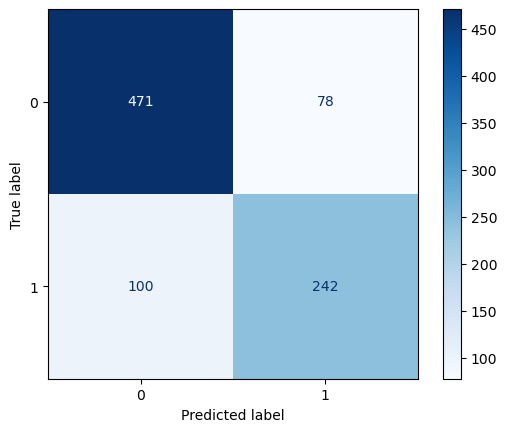

Model [LDA]:
+ params = {'covariance_estimator': None, 'n_components': None, 'priors': None, 'shrinkage': None, 'solver': 'svd', 'store_covariance': False, 'tol': 0.0001}
+ acc = [0.7821229050279329, 0.7865168539325843, 0.797752808988764, 0.7865168539325843, 0.8426966292134831]
+ mean_acc = 0.799121 +/- 0.022394

Confusion matrix on training set for [LDA]:


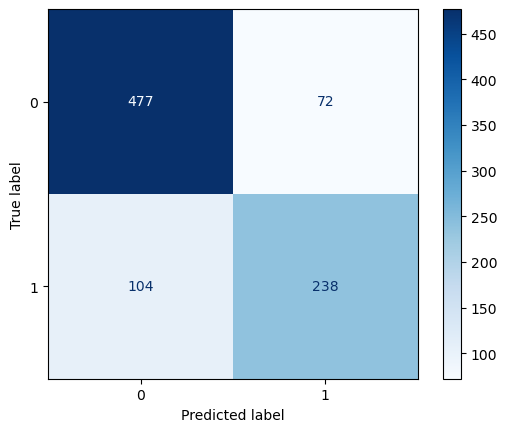

Model [KNN]:
+ params = {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
+ acc = [0.8212290502793296, 0.8033707865168539, 0.7696629213483146, 0.8314606741573034, 0.7921348314606742]
+ mean_acc = 0.803572 +/- 0.021773

Confusion matrix on training set for [KNN]:


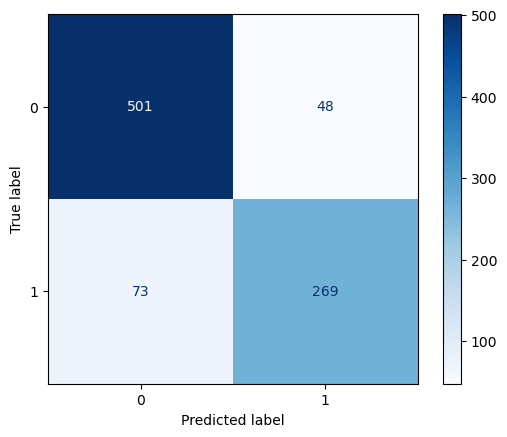

Model [CART]:
+ params = {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
+ acc = [0.776536312849162, 0.8033707865168539, 0.7303370786516854, 0.7584269662921348, 0.8089887640449438]
+ mean_acc = 0.775532 +/- 0.029088

Confusion matrix on training set for [CART]:


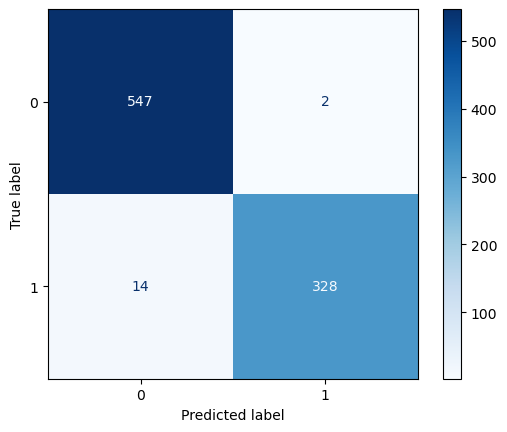

Model [NB]:
+ params = {'priors': None, 'var_smoothing': 1e-09}
+ acc = [0.7877094972067039, 0.8033707865168539, 0.7865168539325843, 0.8033707865168539, 0.8033707865168539]
+ mean_acc = 0.796868 +/- 0.007973

Confusion matrix on training set for [NB]:


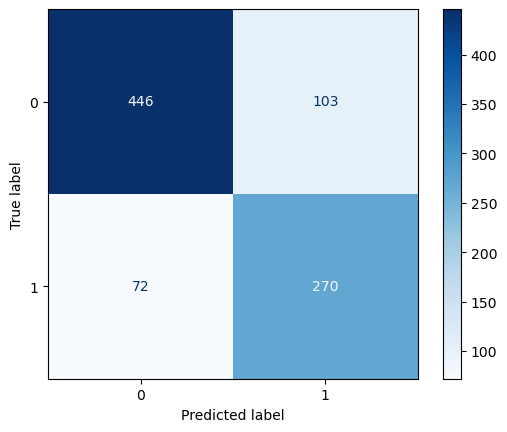

Model [SVM]:
+ params = {'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}
+ acc = [0.8268156424581006, 0.8202247191011236, 0.8314606741573034, 0.8258426966292135, 0.8539325842696629]
+ mean_acc = 0.831655 +/- 0.011698

Confusion matrix on training set for [SVM]:


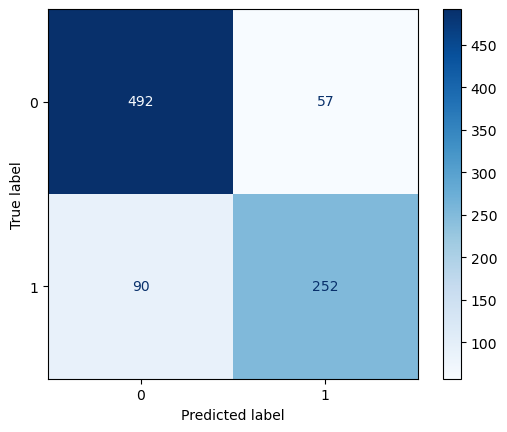

In [77]:
# Mô hình mặc định (models, results, hyper-parameters)
baseline_models  = {}
baseline_results = {}

# khởi tạo các tham số mặc định
baseline_models['LR']   = LogisticRegression(random_state=params["random_state"])
baseline_models['LDA']  = LinearDiscriminantAnalysis()
baseline_models['KNN']  = KNeighborsClassifier()
baseline_models['CART'] = DecisionTreeClassifier(random_state=params["random_state"])
baseline_models['NB']   = GaussianNB()
baseline_models['SVM']  = SVC(random_state=params["random_state"])

# Huấn luyện từng mô hình cơ sở
for model_name in baseline_models:

    baseline_results[model_name] = []

    print(f'Model [{model_name}]:')

    # Chiến lược chia dữ liệu trên tập X_train
    kfold = StratifiedKFold(n_splits=params["k_fold"], shuffle=True, random_state=params["random_state"])

    # Tách X_train, y_train thành 2 tập train, valid trên từng fold
    # Với mỗi fold, train cho huấn luyện, valid cho lượng giá và điều chỉnh tham số
    for fold, (train_idx, valid_idx) in enumerate(kfold.split(X_train, y_train)):
        # Chia 2 tập thành train/valid
        X1_train, y1_train = X_train[train_idx], y_train[train_idx]
        X1_valid, y1_valid = X_train[valid_idx], y_train[valid_idx]


        # Lấy mô hình khởi tạo
        model_clf = sklearn.base.clone(baseline_models[model_name])

        # Huấn luyện mô hình
        model_clf.fit(X1_train, y1_train)

        # Lượng giá mô hình
        y1_pred_valid = model_clf.predict(X1_valid)

        # Tính toán metrics: accuracy
        valid_acc = accuracy_score(y1_valid, y1_pred_valid)
        

        # Lưu metrics trên từng fold
        baseline_results[model_name].append(valid_acc)

        pass # fold
    # Chúng ta đơn giản sử dụng lệnh bên dưới thay cho khối lệnh k-fold bên trên
    # baseline_results[name] = cross_val_score(model_clf, X_train, y_train, cv = kfold, scoring="accuracy")

    # hiển thị tham số mô hình
    print(f'+ params = {baseline_models[model_name].get_params()}')

    # hiển thị kết quả trên từng fold
    print(f'+ acc = {baseline_results[model_name]}')

    # trung bình kết quả +/ std cho tất cả các fold,
    # std: độ lệch chuẩn=> nếu cùng mean thì độ lệch nào nhỏ hơn thì tốt hơn vì ổn định và tập trung hơn
    s_msg = f'+ mean_acc = {np.mean(baseline_results[model_name]):.6f} +/- {np.std(baseline_results[model_name]):.6f}'
    print(s_msg)
    print()
    # Huấn luyện lại với trên toàn bộ dữ liệu train (re-fit all train_data)
    baseline_models[model_name].fit(X_train, y_train)

    y_pred_train = baseline_models[model_name].predict(X_train)
    cm = confusion_matrix(y_train, y_pred_train)
    print(f'Confusion matrix on training set for [{model_name}]:')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    
    disp.plot(cmap='Blues')
    plt.show() 

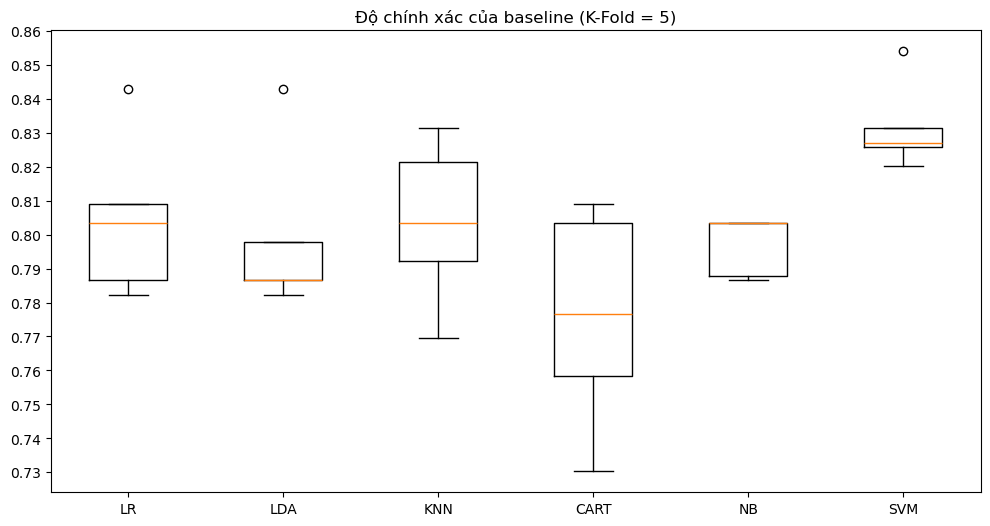

In [78]:
# In biểu đồ box-plot trên độ chính xác với k-fold
plt.figure(figsize=(12,6))
plt.boxplot(baseline_results.values())
plt.gca().set_xticklabels(baseline_results.keys())
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.01))
plt.title(f'Độ chính xác của baseline (K-Fold = {params["k_fold"]})')
plt.show()

### 6.2. Tinh chỉnh mô hình (Tuning Models)


==================== TUNING KNN ====================
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best CV Score : 0.8114
Train Accuracy: 0.8496
Best Params   : {'n_neighbors': 7}

==================== TUNING SVM ====================
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best CV Score : 0.8249
Train Accuracy: 0.8305
Best Params   : {'kernel': 'rbf', 'gamma': 'auto', 'C': 1}


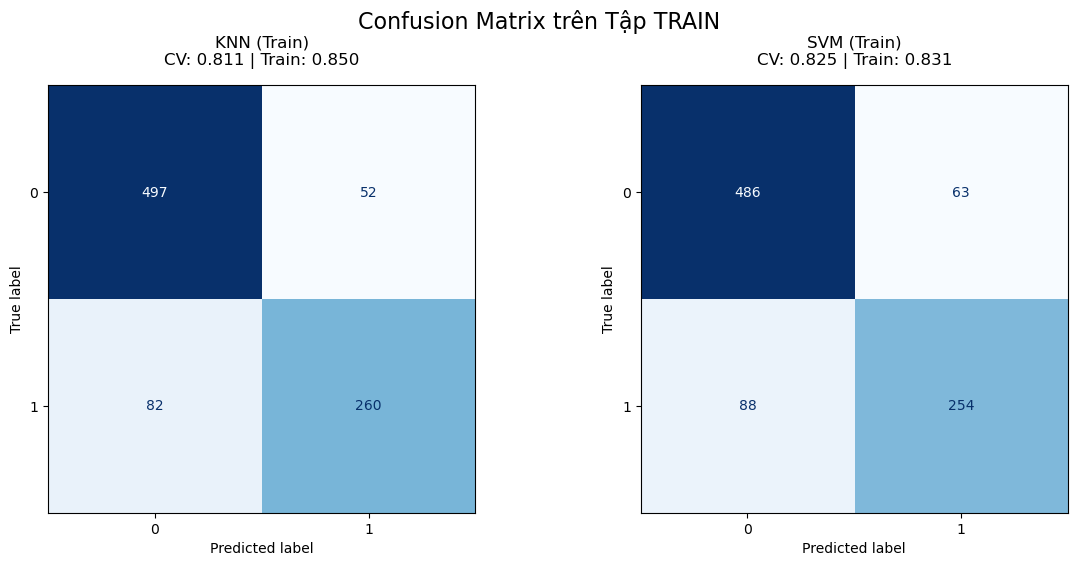


TỔNG KẾT TUNING
KNN   | CV: 0.8114 | Train Acc: 0.8496
SVM   | CV: 0.8249 | Train Acc: 0.8305


In [79]:
# ==================== IMPORT THƯ VIỆN ====================
from sklearn.model_selection import (
    GridSearchCV, KFold, RandomizedSearchCV, train_test_split
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from joblib import parallel_backend
import matplotlib.pyplot as plt
import numpy as np

# ==================== DỮ LIỆU (GIẢ SỬ ĐÃ CÓ) ====================
# X_train, X_test, y_train, y_test
# params = {"k_fold": 5, "random_state": 42}

# ==================== CÀI ĐẶT TUNING ====================
tunning_results = {
    "best_clf": {},
    "best_score": {},
    "train_accuracy": {}  # Thêm để lưu độ chính xác trên train
}

tunning_models = {}
tunning_params = {}

# --- KNN ---
tunning_models['KNN'] = KNeighborsClassifier()
tunning_params['KNN'] = {
    'n_neighbors': [3, 5, 7, 9]  # Giảm số lượng tham số → nhanh hơn
}

# --- SVM ---
tunning_models['SVM'] = SVC(
    decision_function_shape='ovr',
    class_weight='balanced',
    probability=True,
    random_state=params["random_state"]
)
tunning_params['SVM'] = {
    'kernel': ['rbf'],           # Chỉ dùng RBF (nhanh + hiệu quả)
    'C': [1, 10, 100],
    'gamma': ['scale', 'auto']   # Tự động điều chỉnh theo dữ liệu
}

# ==================== VÒNG LẶP TUNING + VẼ CONFUSION MATRIX TRÊN TRAIN ====================
n_models = len(tunning_models)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5.5))
if n_models == 1:
    axes = [axes]  # Đảm bảo axes là iterable

model_names = list(tunning_models.keys())

for idx, model_name in enumerate(model_names):
    print(f"\n{'='*20} TUNING {model_name} {'='*20}")

    # Cross-validation
    kfold = KFold(
        n_splits=params["k_fold"],
        shuffle=True,
        random_state=params["random_state"]
    )

    # Chọn chiến lược tìm kiếm
    if model_name == 'KNN':
        search = GridSearchCV(
            estimator=tunning_models[model_name],
            param_grid=tunning_params[model_name],
            cv=kfold,
            scoring='accuracy',
            n_jobs=-1,           # Dùng tất cả CPU
            verbose=1
        )
    else:  # SVM
        search = RandomizedSearchCV(
            estimator=tunning_models[model_name],
            param_distributions=tunning_params[model_name],
            n_iter=8,            # Thử 8 tổ hợp thay vì full grid
            cv=kfold,
            scoring='accuracy',
            n_jobs=-1,
            random_state=params["random_state"],
            verbose=1
        )

    # === FIT VỚI TỐI ƯU HÓA SONG SONG ===
    with parallel_backend('loky'):
        search.fit(X_train, y_train)

    # === LẤY MÔ HÌNH TỐT NHẤT ===
    best_model = search.best_estimator_
    tunning_results["best_clf"][model_name] = best_model
    tunning_results["best_score"][model_name] = search.best_score_

    # === DỰ ĐOÁN TRÊN TẬP TRAIN ===
    y_pred_train = best_model.predict(X_train)
    train_acc = accuracy_score(y_train, y_pred_train)
    tunning_results["train_accuracy"][model_name] = train_acc

    # === IN KẾT QUẢ ===
    print(f"Best CV Score : {search.best_score_:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Best Params   : {search.best_params_}")

    # Cảnh báo overfitting
    if train_acc > search.best_score_ + 0.05:
        print("Cảnh báo: Mô hình có thể bị overfitting!")

    # === VẼ CONFUSION MATRIX TRÊN TẬP TRAIN ===
    cm = confusion_matrix(y_train, y_pred_train)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=best_model.classes_
    )
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d', colorbar=False)
    axes[idx].set_title(
        f'{model_name} (Train)\n'
        f'CV: {search.best_score_:.3f} | Train: {train_acc:.3f}',
        fontsize=12, pad=15
    )

# === HIỂN THỊ TẤT CẢ CONFUSION MATRIX ===
plt.tight_layout()
plt.suptitle('Confusion Matrix trên Tập TRAIN', fontsize=16, y=1.02)
plt.show()

# ==================== IN TỔNG KẾT ====================
print("\n" + "="*60)
print("TỔNG KẾT TUNING")
print("="*60)
for name in model_names:
    print(f"{name:5} | CV: {tunning_results['best_score'][name]:.4f} | "
          f"Train Acc: {tunning_results['train_accuracy'][name]:.4f}")

## 7. Kiểm nghiệm kết quả trên Test (Finalize Model)

### Load và tiền xử lý tập test

In [80]:
df_test = pd.read_csv(f'{params["exps_dir"]}/data/test_preprocessed.csv')
passenger_ids = df_test['PassengerId'].copy()  # Lưu ID để submit
print("Test: ", len(df_test))
display.display(df_test.head())

Test:  418


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Family_cate,Title
0,892,3,1,34.5,0,0,7.8292,1,1,0,2
1,893,3,0,47.0,1,0,7.0000,2,2,3,3
2,894,2,1,62.0,0,0,9.6875,1,1,0,2
3,895,3,1,27.0,0,0,8.6625,2,1,0,2
4,896,3,0,22.0,1,1,12.2875,2,3,3,3


In [81]:
standard_scaler = joblib.load(f'{params["exps_dir"]}/feature1/standard_scaler.joblib')
scale_columns = dict(np.load(f'{params["exps_dir"]}/feature1/scale_columns.npz'))['scale_columns']

df_test.drop(columns=["PassengerId"], inplace=True)
df_test[scale_columns] = standard_scaler.transform(df_test[scale_columns])
display.display(df_test.head())

X_test = df_test.values  # <-- Đây là biến dùng để dự đoán
print("Test: ", len(df_test))

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Family_cate,Title
0,3,1,0.394887,-0.474545,-0.473674,-0.490783,1,-0.560975,0,2
1,3,0,1.355510,0.432793,-0.473674,-0.507479,2,0.059160,3,3
2,2,1,2.508257,-0.474545,-0.473674,-0.453367,1,-0.560975,0,2
3,3,1,-0.181487,-0.474545,-0.473674,-0.474005,2,-0.560975,0,2
4,3,0,-0.565736,0.432793,0.767630,-0.401017,2,0.679295,3,3


Test:  418



BẮT ĐẦU DỰ ĐOÁN & LƯU KẾT QUẢ TRÊN TẬP TEST

→ [KNN] Đang dự đoán trên tập test...
   Đã lưu submission: ../exps/result1_Titanic_Survival_02_standard\submissions\submission_knn.csv
   Đã lưu model: ../exps/result1_Titanic_Survival_02_standard\models\best_knn.joblib

→ [SVM] Đang dự đoán trên tập test...
   Đã lưu submission: ../exps/result1_Titanic_Survival_02_standard\submissions\submission_svm.csv
   Đã lưu model: ../exps/result1_Titanic_Survival_02_standard\models\best_svm.joblib

TỔNG KẾT HIỆU SUẤT MÔ HÌNH
Model  CV Score  Train Acc         Submission
  SVM    0.8249     0.8305 submission_svm.csv
  KNN    0.8114     0.8496 submission_knn.csv

Đã lưu biểu đồ: ../exps/result1_Titanic_Survival_02_standard\model_comparison.png


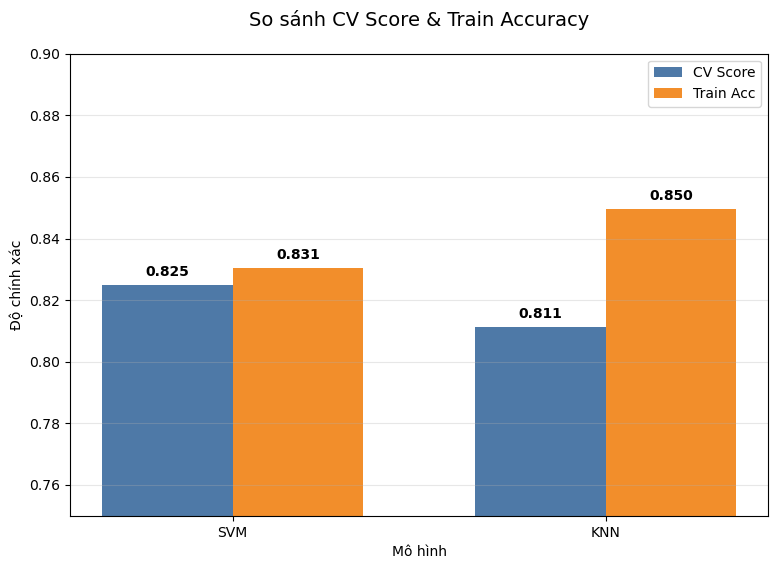


GỢI Ý SUBMIT KAGGLE
   Mô hình tốt nhất: SVM
   CV Score: 0.8249 | Train Acc: 0.8305
   → Ổn định
   NÊN SUBMIT: submission_svm.csv
   Đường dẫn: ../exps/result1_Titanic_Survival_02_standard\submissions\submission_svm.csv


In [82]:
# ==================== TẠO THƯ MỤC LƯU KẾT QUẢ ====================
submission_dir = os.path.join(params["save_dir"], "submissions")
model_dir = os.path.join(params["save_dir"], "models")
os.makedirs(submission_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

submission_paths = {}

print(f"\n{'='*70}")
print("BẮT ĐẦU DỰ ĐOÁN & LƯU KẾT QUẢ TRÊN TẬP TEST")
print(f"{'='*70}")

# ==================== DỰ ĐOÁN + LƯU SUBMISSION & MODEL ====================
for model_name, best_model in tunning_results["best_clf"].items():
    print(f"\n→ [{model_name}] Đang dự đoán trên tập test...")
    
    # Dự đoán
    y_pred_test = best_model.predict(X_test)
    
    # Tạo submission
    submission = pd.DataFrame({
        'PassengerId': passenger_ids,
        'Survived': y_pred_test
    })
    
    # Lưu submission
    sub_path = os.path.join(submission_dir, f"submission_{model_name.lower()}.csv")
    submission.to_csv(sub_path, index=False)
    submission_paths[model_name] = sub_path
    print(f"   Đã lưu submission: {sub_path}")
    
    # Lưu model
    model_path = os.path.join(model_dir, f"best_{model_name.lower()}.joblib")
    joblib.dump(best_model, model_path)
    print(f"   Đã lưu model: {model_path}")

# ==================== TỔNG HỢP KẾT QUẢ ====================
results = []
for name in tunning_results["best_clf"]:
    results.append({
        'Model': name,
        'CV Score': round(tunning_results["best_score"][name], 4),
        'Train Acc': round(tunning_results["train_accuracy"][name], 4),
        'Submission': os.path.basename(submission_paths[name])
    })

results_df = pd.DataFrame(results).sort_values('CV Score', ascending=False)

print(f"\n{'='*80}")
print("TỔNG KẾT HIỆU SUẤT MÔ HÌNH")
print(f"{'='*80}")
print(results_df.to_string(index=False))

# ==================== BIỂU ĐỒ SO SÁNH ====================
plt.figure(figsize=(9, 6))
x = np.arange(len(results_df))
width = 0.35

bars1 = plt.bar(x - width/2, results_df['CV Score'], width, label='CV Score', color='#4e79a7')
bars2 = plt.bar(x + width/2, results_df['Train Acc'], width, label='Train Acc', color='#f28e2b')

# Ghi số trên cột
for bar in bars1 + bars2:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.002, f'{h:.3f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('So sánh CV Score & Train Accuracy', fontsize=14, pad=20)
plt.xlabel('Mô hình')
plt.ylabel('Độ chính xác')
plt.xticks(x, results_df['Model'])
plt.ylim(0.75, 0.9)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Lưu biểu đồ
chart_path = os.path.join(params["save_dir"], "model_comparison.png")
plt.savefig(chart_path, dpi=200, bbox_inches='tight')
print(f"\nĐã lưu biểu đồ: {chart_path}")
plt.show()

# ==================== SUBMIT ====================
best = results_df.iloc[0]
risk = "Có nguy cơ overfitting" if (best['Train Acc'] - best['CV Score']) > 0.05 else "Ổn định"

print(f"\n{'='*60}")
print("GỢI Ý SUBMIT KAGGLE")
print(f"{'='*60}")
print(f"   Mô hình tốt nhất: {best['Model']}")
print(f"   CV Score: {best['CV Score']:.4f} | Train Acc: {best['Train Acc']:.4f}")
print(f"   → {risk}")
print(f"   NÊN SUBMIT: {best['Submission']}")
print(f"   Đường dẫn: {submission_paths[best['Model']]}")